In [1]:
!pip install mglearn
!pip install tensorflow

/usr/lib/python3/dist-packages/secretstorage/dhcrypto.py:15: CryptographyDeprecationWarning: Python 3.8 is no longer supported by the Python core team and support for it is deprecated in cryptography. The next release of cryptography will remove support for Python 3.8.
  from cryptography.utils import int_from_bytes
/usr/lib/python3/dist-packages/secretstorage/dhcrypto.py:15: CryptographyDeprecationWarning: Python 3.8 is no longer supported by the Python core team and support for it is deprecated in cryptography. The next release of cryptography will remove support for Python 3.8.
  from cryptography.utils import int_from_bytes


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import mglearn
import tensorflow as tf
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Dense

In [14]:
np.random.seed(180)
tf.random.set_seed(180)

In [15]:
people=fetch_lfw_people(min_faces_per_person=20,resize=0.7)
print(people.data.shape)
print(people.target.shape)
image_shape=people.images[0].shape

(3023, 5655)
(3023,)


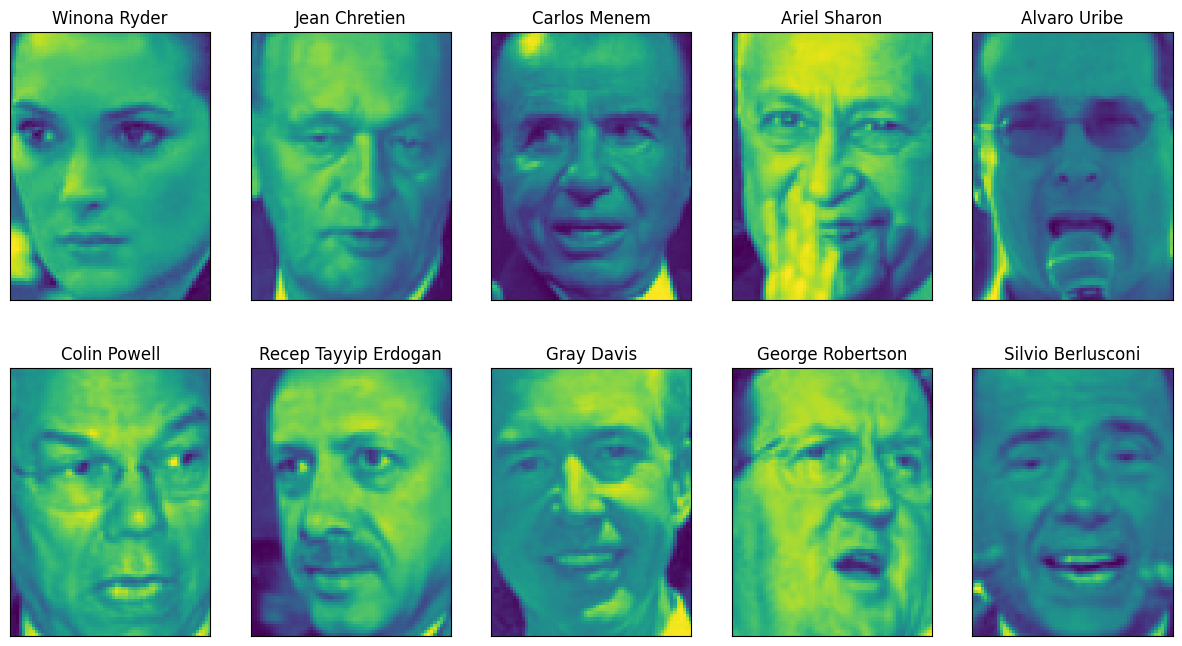

In [19]:
fix,axes=plt.subplots(2,5,figsize=(15,8),subplot_kw={'xticks':(),'yticks':()})
for target,image,ax in zip(people.target,people.images,axes.ravel()):
    ax.imshow(image)
    ax.set_title(people.target_names[target])
plt.show()

In [17]:
X_train,X_test,y_train,y_test=train_test_split(people.data,people.target,test_size=0.2,random_state=20)
y_train=y_train.astype(int)
y_test=y_test.astype(int)
batch_size=len(X_train)
print(X_train.shape,y_train.shape,y_test.shape)
print("people.image.shape:{}".format(people.images.shape))
print("Number of classes:{}".format(len(people.target_names)))

(2418, 5655) (2418,) (605,)
people.image.shape:(3023, 87, 65)
Number of classes:62


In [21]:
count=np.bincount(people.target)
for i,(count,name) in enumerate(zip(count,people.target_names)):
    print("{0:25} {1:3}".format(name,count),end="")
    if(i+1)%3==0:
        print()

Alejandro Toledo           39Alvaro Uribe               35Amelie Mauresmo            21
Andre Agassi               36Angelina Jolie             20Ariel Sharon               77
Arnold Schwarzenegger      42Atal Bihari Vajpayee       24Bill Clinton               29
Carlos Menem               21Colin Powell              236David Beckham              31
Donald Rumsfeld           121George Robertson           22George W Bush             530
Gerhard Schroeder         109Gloria Macapagal Arroyo    44Gray Davis                 26
Guillermo Coria            30Hamid Karzai               22Hans Blix                  39
Hugo Chavez                71Igor Ivanov                20Jack Straw                 28
Jacques Chirac             52Jean Chretien              55Jennifer Aniston           21
Jennifer Capriati          42Jennifer Lopez             21Jeremy Greenstock          24
Jiang Zemin                20John Ashcroft              53John Negroponte            31
Jose Maria Aznar           23Jua

In [25]:
mask=np.zeros(people.target.shape,dtype=np.bool_)
for target in np.unique(people.target):
    mask[np.where(people.target==target)[0][:50]]=True
X_people=people.data[mask]
y_people=people.target[mask]
X_people=X_people/255.0

In [26]:
X_train,X_test,y_train,y_test=train_test_split(X_people,y_people,stratify=y_people,random_state=0)
knn=KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train,y_train)
print("Test set score of l-nn:{:2f}".format(knn.score(X_test,y_test)))

Test set score of l-nn:0.215116


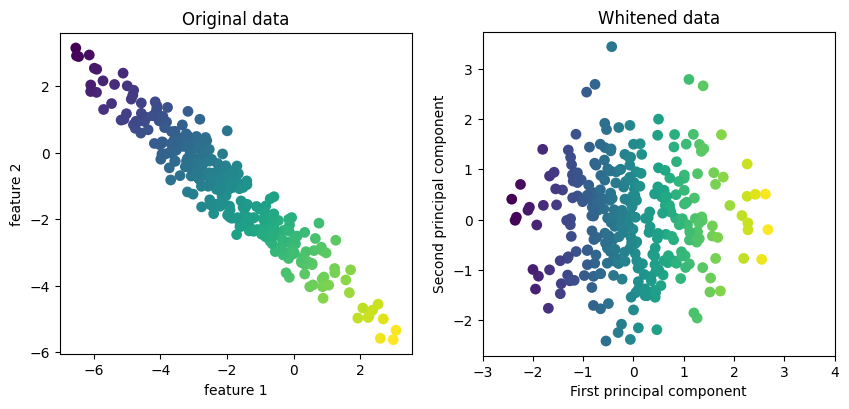

In [28]:
mglearn.plots.plot_pca_whitening()
plt.show()

In [30]:
pca=PCA(n_components=100,whiten=True,random_state=0).fit(X_train)
X_train_pca=pca.transform(X_train)
X_test_pca=pca.transform(X_test)
print("X_train_pca.shape:{}".format(X_train_pca.shape))
#KNN with PCA
knn=KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train_pca,y_train)
print("Test set accuracy:{:2f}".format(knn.score(X_test_pca,y_test)))
print("pca.components_.shape:{}".format(pca.components_.shape))

X_train_pca.shape:(1547, 100)
Test set accuracy:0.296512
pca.components_.shape:(100, 5655)


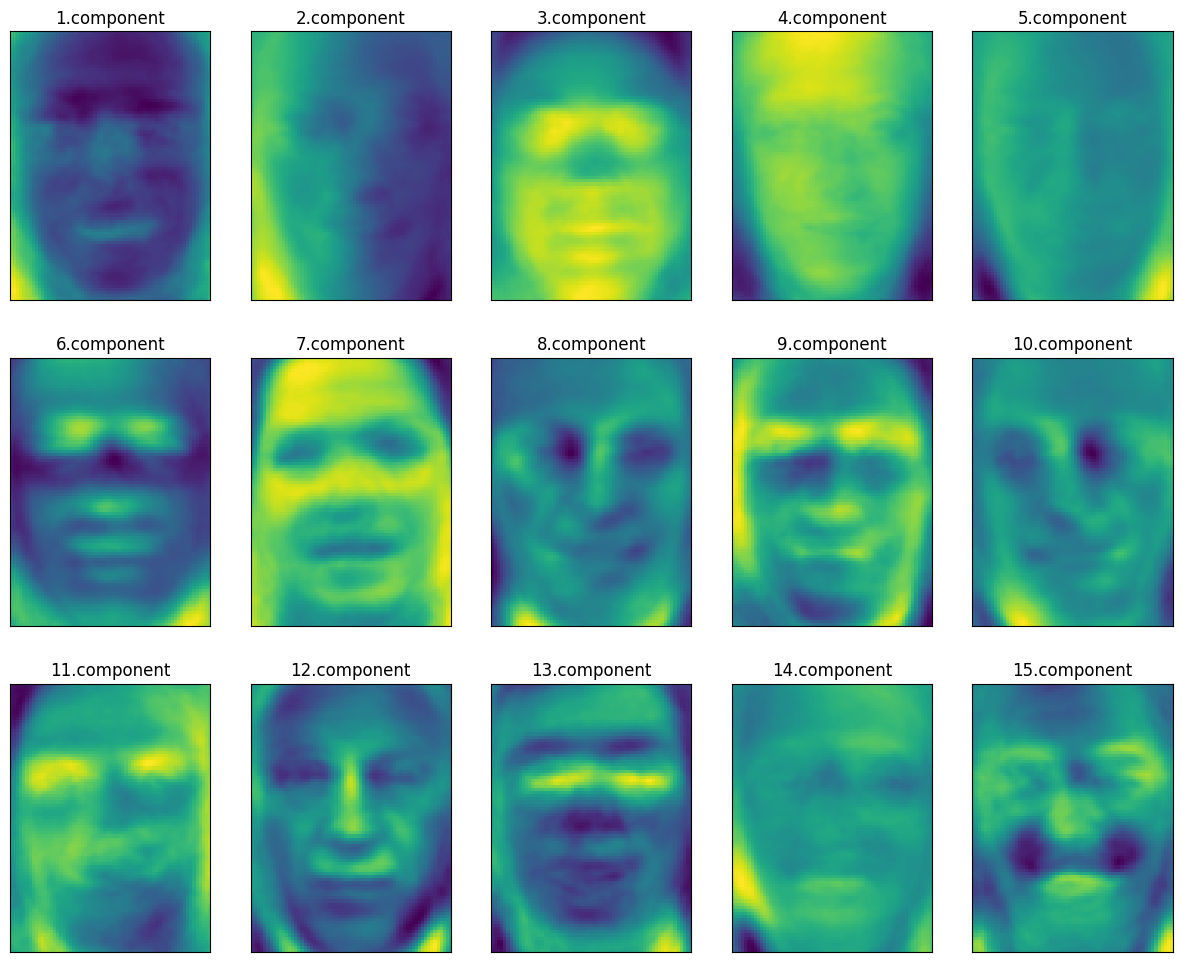

In [32]:
fix,axes=plt.subplots(3,5,figsize=(15,12),subplot_kw={'xticks':(),'yticks':()})
for i,(component,ax)in enumerate(zip(pca.components_,axes.ravel())):
    ax.imshow(component.reshape(image_shape),cmap='viridis')
    ax.set_title("{}.component".format(i+1))
plt.show()

In [33]:
scaler=MinMaxScaler()
X_train_scaled=scaler.fit_transform(X_train_pca)
X_test_scaled=scaler.transform(X_test_pca)

In [36]:
model=Sequential([Input(shape=(100,)),Dense(300,activation='relu'),Dense(100,activation='relu'),Dense(len(np.unique(y_train)),activation='softmax')])

In [38]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [40]:
history=model.fit(X_train_scaled,y_train,batch_size=50,epochs=20,shuffle=False,verbose=1)

Epoch 1/20
31/31 [==============================] - 1s 5ms/step - loss: 4.1268 - accuracy: 0.0155
Epoch 2/20
31/31 [==============================] - 0s 6ms/step - loss: 4.0943 - accuracy: 0.0284
Epoch 3/20
31/31 [==============================] - 0s 5ms/step - loss: 4.0763 - accuracy: 0.0291
Epoch 4/20
31/31 [==============================] - 0s 5ms/step - loss: 4.0581 - accuracy: 0.0284
Epoch 5/20
31/31 [==============================] - 0s 5ms/step - loss: 4.0420 - accuracy: 0.0310
Epoch 6/20
31/31 [==============================] - 0s 5ms/step - loss: 4.0180 - accuracy: 0.0452
Epoch 7/20
31/31 [==============================] - 0s 5ms/step - loss: 3.9809 - accuracy: 0.0633
Epoch 8/20
31/31 [==============================] - 0s 5ms/step - loss: 3.9372 - accuracy: 0.0840
Epoch 9/20
31/31 [==============================] - 0s 6ms/step - loss: 3.8825 - accuracy: 0.1080
Epoch 10/20
31/31 [==============================] - 0s 4ms/step - loss: 3.8121 - accuracy: 0.1357
Epoch 11/20
31/31 [

In [42]:
loss,accuracy=model.evaluate(X_test_scaled,y_test,verbose=1)
print("Test Loss:",loss)
print("Test Accuracy:",accuracy)

17/17 [==============================] - 0s 3ms/step - loss: 2.9100 - accuracy: 0.3275
Test Loss: 2.910046100616455
Test Accuracy: 0.32751938700675964
